# Quantum Harmonic Oscillator on a Grid

This notebook discretizes the dimensionless harmonic oscillator

$$H=-\frac{1}{2}\frac{d^2}{dx^2}+\frac{1}{2}x^2.$$

The exact energies are `n + 1/2`. We compare the finite-difference spectrum with this analytic result and use a low-energy polynomial filter to isolate the ground state.


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a finite-difference harmonic oscillator grid.

**QSVT implementation.** It uses polynomial filtering to emphasize low-energy oscillator modes. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Analytic and finite-difference spectra validate the grid model. This is a compact check of spectral matrix functions on a familiar quantum system, relevant to larger grid Hamiltonians with block encodings.


## Variable definitions

- `n_points`: number of grid points.
- `xmax`: half-width of the coordinate domain.
- `length`: full coordinate-domain length.
- `x`, `dx`: grid coordinates and spacing.
- `negative_laplacian`: finite-difference kinetic operator.
- `H`: discretized harmonic-oscillator Hamiltonian.
- `eigenvalues`, `eigenvectors`: numerical spectrum and eigenvectors.
- `analytic`: analytic harmonic-oscillator energies used for comparison.
- `spectrum_error`: error in the first few numerical energies.
- `center`, `half_width`: midpoint and half-width of the spectrum.
- `A`: rescaled Hamiltonian.
- `coeffs`: low-energy filter polynomial coefficients.
- `scaled_evals`, `filter_values`: scaled eigenvalues and polynomial filter response.
- `trial`, `filtered`: trial state and filtered state.
- `ground`: exact numerical ground-state vector.
- `ground_overlap`: filtered-state ground probability.
- `indices`, `fig`, `axes`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.pde import dirichlet_laplacian_1d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 80
xmax = 7.0
length = 2.0 * xmax
dx = length / (n_points + 1)
x = np.linspace(-xmax + dx, xmax - dx, n_points)

_, negative_laplacian = dirichlet_laplacian_1d(n_points, length=length)
H = 0.5 * negative_laplacian + np.diag(0.5 * x**2)

eigenvalues, eigenvectors = eigh_hermitian(H)
analytic = np.arange(6) + 0.5
spectrum_error = np.max(np.abs(eigenvalues[:4] - analytic[:4]))

print(f"Eigenvalues [model energy units]: {eigenvalues[:6]}")
print(f"Spectrum Error [model energy units]: {spectrum_error}")

Eigenvalues [model energy units]: [0.4991 1.4953 2.4878 3.4765 4.4614 5.4424]
Spectrum Error [model energy units]: 0.02350013331927281


In [3]:
center = 0.5 * (eigenvalues[0] + eigenvalues[-1])
half_width = 0.5 * (eigenvalues[-1] - eigenvalues[0])
A = (center * np.eye(n_points) - H) / half_width

coeffs = exponential_approximation_polynomial(degree=18, beta=8.0)
trial = np.exp(-(x**2) / 2.5)
trial = trial / np.linalg.norm(trial)
filtered = apply_polynomial_to_hermitian(A, coeffs) @ trial
filtered = filtered / np.linalg.norm(filtered)

ground = eigenvectors[:, 0]
scaled_evals = np.linalg.eigvalsh(A)
filter_values = np.polynomial.polynomial.polyval(scaled_evals, coeffs)
ground_overlap = np.abs(np.vdot(ground, filtered)) ** 2

print(f"Ground State Overlap [probability]: {ground_overlap}")

Ground State Overlap [probability]: 0.9969945579767748


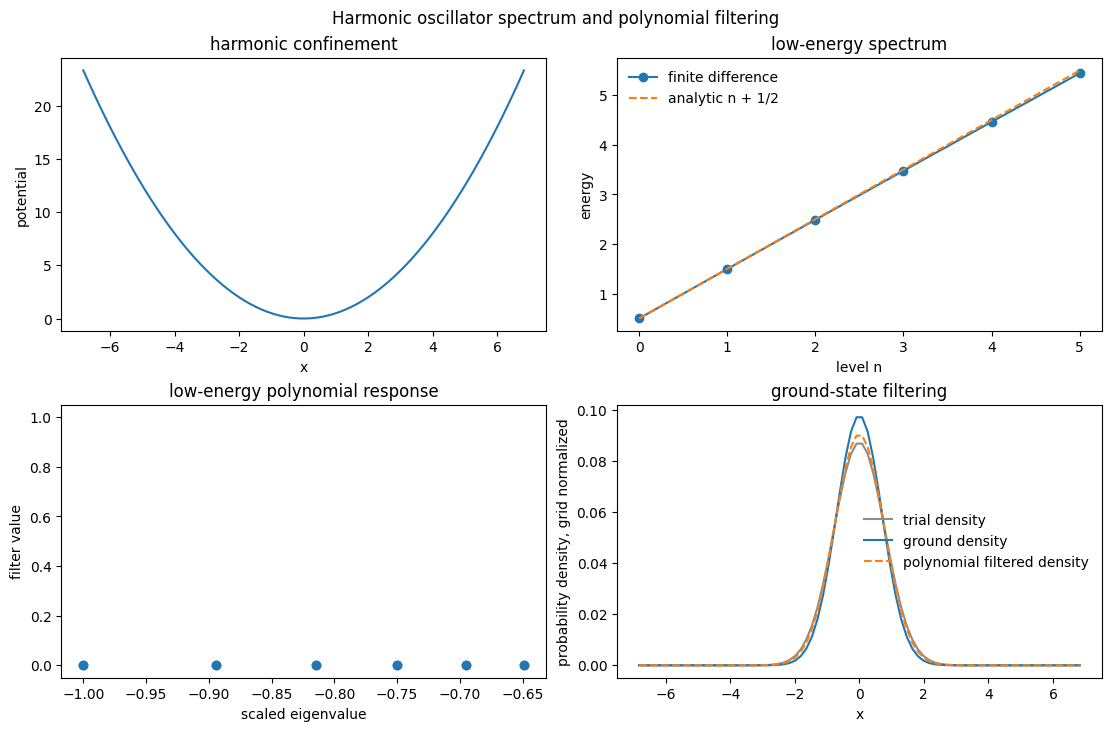

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), constrained_layout=True)

axes[0, 0].plot(x, 0.5 * x**2)
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("potential")
axes[0, 0].set_title("harmonic confinement")

indices = np.arange(6)
axes[0, 1].plot(indices, eigenvalues[:6], "o-", label="finite difference")
axes[0, 1].plot(indices, analytic, "--", label="analytic n + 1/2")
axes[0, 1].set_xlabel("level n")
axes[0, 1].set_ylabel("energy")
axes[0, 1].set_title("low-energy spectrum")
axes[0, 1].legend(frameon=False)

axes[1, 0].plot(scaled_evals[:12], filter_values[:12], "o")
axes[1, 0].set_xlabel("scaled eigenvalue")
axes[1, 0].set_ylabel("filter value")
axes[1, 0].set_title("low-energy polynomial response")
axes[1, 0].set_ylim(-0.05, 1.05)

axes[1, 1].plot(x, trial**2, color="0.55", label="trial density")
axes[1, 1].plot(x, ground**2, label="ground density")
axes[1, 1].plot(x, filtered**2, "--", label="polynomial filtered density")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("probability density, grid normalized")
axes[1, 1].set_title("ground-state filtering")
axes[1, 1].legend(frameon=False)

fig.suptitle("Harmonic oscillator spectrum and polynomial filtering")
plt.show()

## Validation

Compact checks against the analytic oscillator spectrum and filtered ground state.


In [5]:
assert spectrum_error < 0.04
assert ground_overlap > 0.95
assert np.all(np.diff(eigenvalues[:6]) > 0.8)

print(
    "finite_difference_energies [model energy units]:",
    np.array2string(eigenvalues[:6], precision=4),
)
print(
    "analytic_energies [model energy units]:",
    np.array2string(analytic, precision=4),
)
print(f"spectrum_error_first_four [model energy units]: {spectrum_error:.4e}")
print(f"ground_overlap [probability]: {ground_overlap:.4f}")
print("validation: passed")

finite_difference_energies [model energy units]: [0.4991 1.4953 2.4878 3.4765 4.4614 5.4424]
analytic_energies [model energy units]: [0.5 1.5 2.5 3.5 4.5 5.5]
spectrum_error_first_four [model energy units]: 2.3500e-02
ground_overlap [probability]: 0.9970
validation: passed
